In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cafe_limpo.csv")

df["Data"] = pd.to_datetime(df["Data"])

df = df.set_index("Data")

serie_mensal = df["Sacas"].resample("MS").sum()

print(serie_mensal.head())

Data
2016-01-01    2.147871e+06
2016-02-01    2.270584e+06
2016-03-01    2.296132e+06
2016-04-01    1.867115e+06
2016-05-01    1.776538e+06
Freq: MS, Name: Sacas, dtype: float64


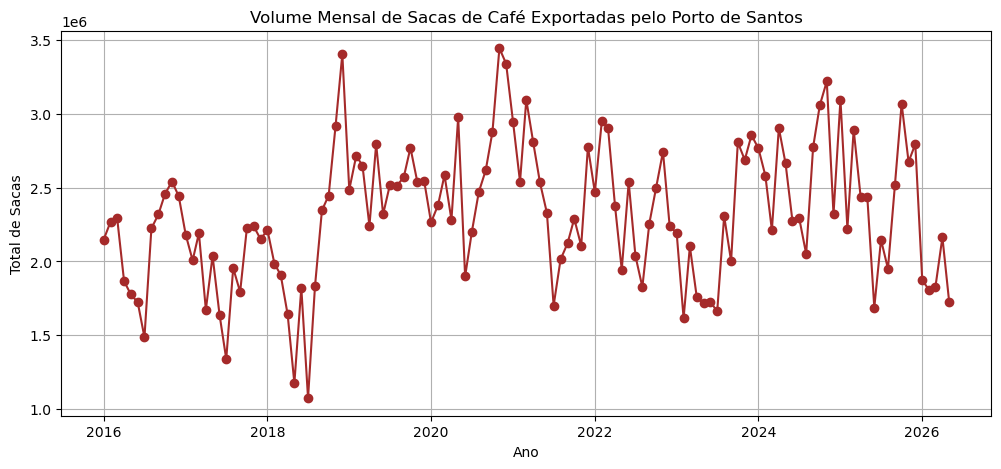

In [2]:
plt.figure(figsize=(12, 5))
plt.plot(serie_mensal, marker='o', color='brown')
plt.title("Volume Mensal de Sacas de Café Exportadas pelo Porto de Santos")
plt.xlabel("Ano")
plt.ylabel("Total de Sacas")
plt.grid(True)
plt.show()

In [3]:
dados_treino = serie_mensal[:"2024-12-31"]
dados_teste = serie_mensal["2025-01-01":"2025-12-31"]

print(f"Meses de histórico para treino (2016-2024): {len(dados_treino)}")
print(f"Meses para validação do teste (2025): {len(dados_teste)}")

Meses de histórico para treino (2016-2024): 108
Meses para validação do teste (2025): 12


In [4]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo = SARIMAX(dados_treino, 
                 order=(1, 1, 1), 
                 seasonal_order=(1, 1, 1, 12),
                 enforce_stationarity=False,
                 enforce_invertibility=False)

resultado = modelo.fit(disp=False)
print("Modelo treinado com sucesso com o histórico desde 2016!")

Modelo treinado com sucesso com o histórico desde 2016!


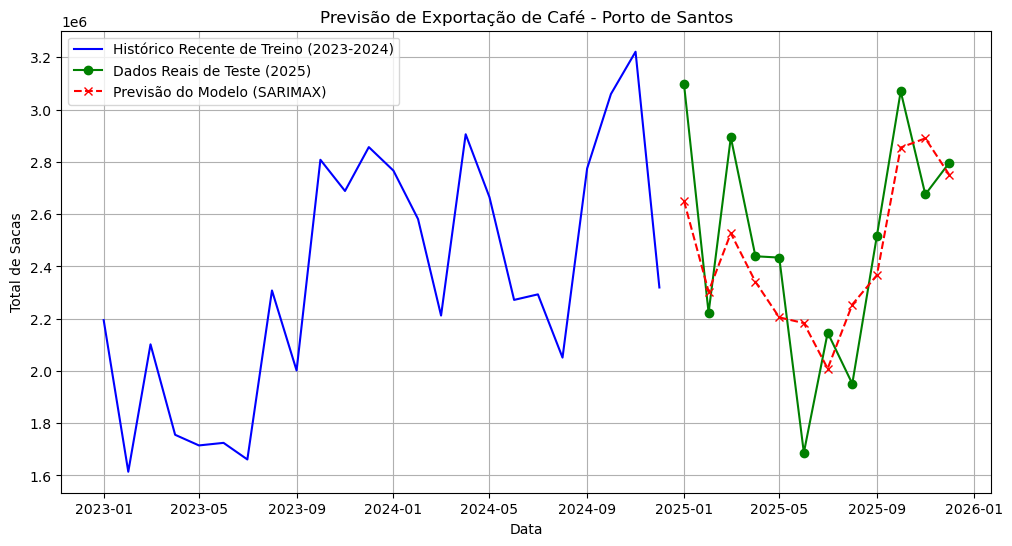

In [5]:
import matplotlib.pyplot as plt

previsoes = resultado.predict(start=dados_teste.index[0], end=dados_teste.index[-1])


plt.figure(figsize=(12, 6))

plt.plot(dados_treino["2023":], label="Histórico Recente de Treino (2023-2024)", color="blue")
plt.plot(dados_teste, label="Dados Reais de Teste (2025)", color="green", marker="o")
plt.plot(previsoes, label="Previsão do Modelo (SARIMAX)", color="red", linestyle="--", marker="x")

plt.title("Previsão de Exportação de Café - Porto de Santos")
plt.xlabel("Data")
plt.ylabel("Total de Sacas")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_final = SARIMAX(serie_mensal, 
                       order=(1, 1, 1), 
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
resultado_final = modelo_final.fit(disp=False)

previsao_futura = resultado_final.get_forecast(steps=6)
sacas_previstas = previsao_futura.predicted_mean

conteineres_previstos = (sacas_previstas / 440).round(0)

tabela_logistica = pd.DataFrame({
    "Volume Previsto (Sacas)": sacas_previstas.round(0).astype(int),
    "Contêineres de 40' Necessários": conteineres_previstos.astype(int)
})

print("PLANEJAMENTO LOGÍSTICO DE EXPORTAÇÃO - PORTO DE SANTOS ")
print(tabela_logistica)

PLANEJAMENTO LOGÍSTICO DE EXPORTAÇÃO - PORTO DE SANTOS 
            Volume Previsto (Sacas)  Contêineres de 40' Necessários
2026-06-01                  1574651                            3579
2026-07-01                  1542871                            3507
2026-08-01                  1551070                            3525
2026-09-01                  1958181                            4450
2026-10-01                  2392547                            5438
2026-11-01                  2383061                            5416
